<a href="https://colab.research.google.com/github/tanushvi/Visual-Question-Answering/blob/main/VQA_Hybrid_ResNet50_BERT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu130
GPU available: True
GPU: Tesla T4


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

print(os.listdir('/content/drive/MyDrive/VQA_Project'))

['archive (2).zip']


In [8]:
import os

for root, dirs, files in os.walk('/content/drive'):
    for file in files:
        if file == 'archive(2).zip':
            print("Found at:")
            print(os.path.join(root, file))

In [10]:
import zipfile

zip_path = '/content/drive/MyDrive/VQA_Project/archive (2).zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    files = zip_ref.namelist()

print("Number of files:", len(files))

for file in files[:50]:
    print(file)

Number of files: 1456
all_qa_pairs.txt
answer_space.txt
data.csv
data_eval.csv
data_train.csv
images/image1.png
images/image10.png
images/image100.png
images/image1000.png
images/image1001.png
images/image1002.png
images/image1003.png
images/image1004.png
images/image1005.png
images/image1006.png
images/image1007.png
images/image1008.png
images/image1009.png
images/image101.png
images/image1010.png
images/image1011.png
images/image1012.png
images/image1013.png
images/image1014.png
images/image1015.png
images/image1016.png
images/image1017.png
images/image1018.png
images/image1019.png
images/image102.png
images/image1020.png
images/image1021.png
images/image1022.png
images/image1023.png
images/image1024.png
images/image1025.png
images/image1026.png
images/image1027.png
images/image1028.png
images/image1029.png
images/image103.png
images/image1030.png
images/image1031.png
images/image1032.png
images/image1033.png
images/image1034.png
images/image1035.png
images/image1036.png
images/image

In [11]:
import zipfile
import pandas as pd
from io import TextIOWrapper

zip_path = '/content/drive/MyDrive/VQA_Project/archive (2).zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    with zip_ref.open('data_train.csv') as f:
        train_df = pd.read_csv(f)

    with zip_ref.open('data_eval.csv') as f:
        eval_df = pd.read_csv(f)

print("TRAIN DATA")
print("Shape:", train_df.shape)
print("Columns:", train_df.columns.tolist())
print()
print(train_df.head())

TRAIN DATA
Shape: (6795, 3)
Columns: ['question', 'answer', 'image_id']

                                            question  \
0  what is on the right side of the black telepho...   
1  what is in front of the white door on the left...   
2                                what is on the desk   
3                  what is the largest brown objects   
4  what color is the chair in front of the white ...   

                                  answer image_id  
0                                   desk   image3  
1                              telephone   image3  
2  book, scissor, papers, tape_dispenser   image3  
3                                 carton   image3  
4                                    red   image3  


In [12]:
import zipfile
import pandas as pd

zip_path = '/content/drive/MyDrive/VQA_Project/archive (2).zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:

    with zip_ref.open('data_eval.csv') as f:
        eval_df = pd.read_csv(f)

    with zip_ref.open('answer_space.txt') as f:
        answer_space = f.read().decode('utf-8')

print("EVALUATION DATA")
print("Shape:", eval_df.shape)
print("Columns:", eval_df.columns.tolist())
print()
print(eval_df.head())

print("\nANSWER SPACE")
print(answer_space[:2000])

EVALUATION DATA
Shape: (5673, 3)
Columns: ['question', 'answer', 'image_id']

                                            question           answer image_id
0  what is on the left side of the white oven on ...      garbage_bin   image1
1  what is on the left side of the fire extinguis...            table   image1
2  what is between the the two white and black ga...            chair   image1
3  how many objects are between the fire extingui...                3   image1
4         what is the largest object in this picture  washing_machine   image1

ANSWER SPACE
1
10
11
12
13
14
15
16
18
19
2
2163
22
3
4
5
6
7
8
9
air_conditioner
air_vent
alarm
alarm_clock
album
aluminium_foil
apple
ashtray
baby_chair
baby_gate
back_scrubber
backpack
bag
ball
balloon
banana
banister
bar_of_soap
basket
basketball
basketball_hoop
bathtub
bean_bag
bed
bed_sheets
belt
bench
bicycle
bicycle_helmet
bin
binder
black
blackboard
blanket
blender
blinds
blue
board
book
book_holder
bookrack
books
bookshelf
bottle
bot

In [13]:
import zipfile
import pandas as pd

zip_path = '/content/drive/MyDrive/VQA_Project/archive (2).zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    with zip_ref.open('data_train.csv') as f:
        train_df = pd.read_csv(f)

    with zip_ref.open('data_eval.csv') as f:
        eval_df = pd.read_csv(f)

# Check multiple-answer cases
train_multi = train_df[train_df['answer'].astype(str).str.contains(',')]
eval_multi = eval_df[eval_df['answer'].astype(str).str.contains(',')]

print("TRAINING DATA")
print("Total rows:", len(train_df))
print("Multiple-answer rows:", len(train_multi))
print("Single-answer rows:", len(train_df) - len(train_multi))

print("\nEVALUATION DATA")
print("Total rows:", len(eval_df))
print("Multiple-answer rows:", len(eval_multi))
print("Single-answer rows:", len(eval_df) - len(eval_multi))

print("\nExample multiple answers:")
print(train_multi[['question', 'answer', 'image_id']].head(10))

TRAINING DATA
Total rows: 6795
Multiple-answer rows: 646
Single-answer rows: 6149

EVALUATION DATA
Total rows: 5673
Multiple-answer rows: 597
Single-answer rows: 5076

Example multiple answers:
                                              question  \
2                                  what is on the desk   
14   what is in front of the white board or in fron...   
26   what are on the wall on the left side of the g...   
72          what are the white objects on the mattress   
74   what color is the hat on the top right of the ...   
84   what colors are the sweatshirts in front of th...   
86               what colors are the mugs in the shelf   
88                     what colors are the sweatshirts   
91    what colors are the sticker notes on the shelves   
100                          what color is the counter   

                                    answer  image_id  
2    book, scissor, papers, tape_dispenser    image3  
14                            table, chair    image5  
26

In [14]:
import zipfile
import pandas as pd

zip_path = '/content/drive/MyDrive/VQA_Project/archive (2).zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:

    with zip_ref.open('answer_space.txt') as f:
        answer_space = [
            line.decode('utf-8').strip()
            for line in f
            if line.decode('utf-8').strip()
        ]

    with zip_ref.open('data_train.csv') as f:
        train_df = pd.read_csv(f)

    with zip_ref.open('data_eval.csv') as f:
        eval_df = pd.read_csv(f)

print("Number of answer labels:", len(answer_space))

print("\nFirst 30 answer labels:")
print(answer_space[:30])

print("\nLast 10 answer labels:")
print(answer_space[-10:])

Number of answer labels: 582

First 30 answer labels:
['1', '10', '11', '12', '13', '14', '15', '16', '18', '19', '2', '2163', '22', '3', '4', '5', '6', '7', '8', '9', 'air_conditioner', 'air_vent', 'alarm', 'alarm_clock', 'album', 'aluminium_foil', 'apple', 'ashtray', 'baby_chair', 'baby_gate']

Last 10 answer labels:
['wine_bottle', 'wine_glass', 'wine_rack', 'wire', 'wire_board', 'wooden_plank', 'wooden_planks', 'xbox', 'yellow', 'yoga_mat']


In [15]:
import zipfile
import pandas as pd

zip_path = '/content/drive/MyDrive/VQA_Project/archive (2).zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:

    with zip_ref.open('answer_space.txt') as f:
        answer_space = set(
            line.decode('utf-8').strip()
            for line in f
            if line.decode('utf-8').strip()
        )

    with zip_ref.open('data_train.csv') as f:
        train_df = pd.read_csv(f)

    with zip_ref.open('data_eval.csv') as f:
        eval_df = pd.read_csv(f)


# Split multiple answers and collect every individual answer
def get_individual_answers(df):
    answers = set()

    for answer in df['answer'].astype(str):
        for item in answer.split(','):
            answers.add(item.strip())

    return answers


train_answers = get_individual_answers(train_df)
eval_answers = get_individual_answers(eval_df)

all_answers = train_answers | eval_answers

missing_answers = all_answers - answer_space

print("Unique individual answers in CSV:", len(all_answers))
print("Answer labels in answer_space.txt:", len(answer_space))
print("Answers missing from answer_space.txt:", len(missing_answers))

if missing_answers:
    print("\nMissing answers:")
    print(sorted(missing_answers))
else:
    print("\n✓ Every answer is present in answer_space.txt")

Unique individual answers in CSV: 582
Answer labels in answer_space.txt: 582
Answers missing from answer_space.txt: 0

✓ Every answer is present in answer_space.txt


In [16]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/VQA_Project/archive (2).zip'
extract_path = '/content/drive/MyDrive/VQA_Project/DAQUAR'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")
print("\nFiles and folders:")

for item in os.listdir(extract_path):
    print(item)

Dataset extracted successfully!

Files and folders:
all_qa_pairs.txt
answer_space.txt
data.csv
data_eval.csv
data_train.csv
images
test_images_list.txt
train_images_list.txt


In [17]:
import os

image_folder = '/content/drive/MyDrive/VQA_Project/DAQUAR/images'

images = os.listdir(image_folder)

print("Number of images:", len(images))
print("\nFirst 10 images:")

for image in images[:10]:
    print(image)

Number of images: 1449

First 10 images:
image1.png
image10.png
image100.png
image1000.png
image1001.png
image1002.png
image1003.png
image1004.png
image1005.png
image1006.png


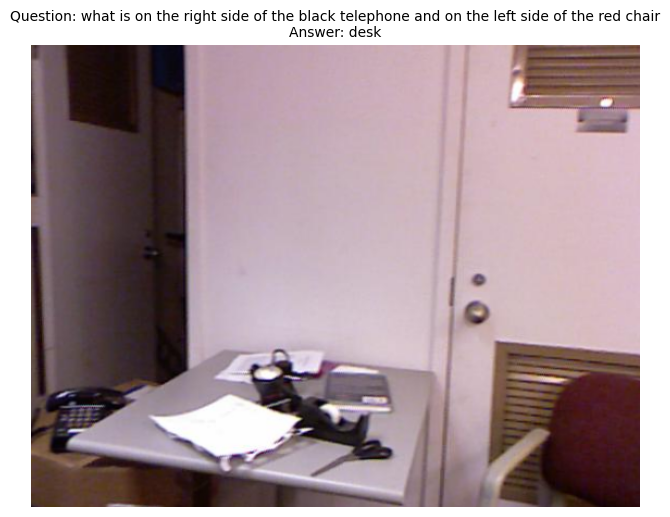

Image ID: image3
Question: what is on the right side of the black telephone and on the left side of the red chair
Answer: desk


In [18]:
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import os

# Load training data
train_path = '/content/drive/MyDrive/VQA_Project/DAQUAR/data_train.csv'
image_folder = '/content/drive/MyDrive/VQA_Project/DAQUAR/images'

train_df = pd.read_csv(train_path)

# Select one example
sample = train_df.iloc[0]

image_id = sample['image_id']
question = sample['question']
answer = sample['answer']

# Image path
image_path = os.path.join(image_folder, image_id + '.png')

# Display image
image = Image.open(image_path)

plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.axis('off')
plt.title(
    f"Question: {question}\nAnswer: {answer}",
    fontsize=10
)
plt.show()

print("Image ID:", image_id)
print("Question:", question)
print("Answer:", answer)

In [19]:
import torch
import torchvision
from torchvision import models, transforms

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

# Image preprocessing for ResNet50
image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Load pretrained ResNet50
resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Remove the final classification layer
resnet = torch.nn.Sequential(*list(resnet.children())[:-1])

# Freeze ResNet50 parameters
for param in resnet.parameters():
    param.requires_grad = False

resnet = resnet.to(device)
resnet.eval()

print("ResNet50 loaded successfully!")
print("Output feature size: 2048")

Device: cuda
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 169MB/s]


ResNet50 loaded successfully!
Output feature size: 2048


In [20]:
!pip install -q transformers

In [21]:
from transformers import BertTokenizer, BertModel

# Load BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Load pretrained BERT
bert = BertModel.from_pretrained('bert-base-uncased')

# Move BERT to GPU
bert = bert.to(device)

# Freeze BERT parameters
for param in bert.parameters():
    param.requires_grad = False

bert.eval()

print("BERT loaded successfully!")
print("BERT hidden size:", bert.config.hidden_size)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT loaded successfully!
BERT hidden size: 768


In [22]:
# Take one real question from our dataset
question = train_df.iloc[0]['question']

print("Question:")
print(question)

# Convert question into BERT tokens
inputs = tokenizer(
    question,
    return_tensors='pt',
    padding=True,
    truncation=True,
    max_length=64
)

# Move inputs to GPU
inputs = {key: value.to(device) for key, value in inputs.items()}

# Extract BERT features
with torch.no_grad():
    outputs = bert(**inputs)

# Use [CLS] representation as the question feature
question_features = outputs.last_hidden_state[:, 0, :]

print("\nQuestion feature shape:")
print(question_features.shape)

Question:
what is on the right side of the black telephone and on the left side of the red chair

Question feature shape:
torch.Size([1, 768])


In [23]:
import torch
import torch.nn as nn

class VQAHybridModel(nn.Module):
    def __init__(self, image_dim=2048, text_dim=768, hidden_dim=512, num_answers=582):
        super().__init__()

        # Convert image features to common dimension
        self.image_projection = nn.Linear(image_dim, hidden_dim)

        # Convert BERT features to common dimension
        self.text_projection = nn.Linear(text_dim, hidden_dim)

        # Attention layer
        self.attention = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)
        )

        # Final fusion layer
        self.fusion = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        # Multi-label answer classifier
        self.classifier = nn.Linear(hidden_dim, num_answers)

    def forward(self, image_features, text_features):

        # Project both modalities
        image_features = self.image_projection(image_features)
        text_features = self.text_projection(text_features)

        # Combine image and text
        combined = torch.cat(
            [image_features, text_features],
            dim=1
        )

        # Calculate attention weight
        attention_weight = torch.sigmoid(
            self.attention(combined)
        )

        # Apply attention to both modalities
        image_attended = image_features * attention_weight
        text_attended = text_features * attention_weight

        # Final fusion
        fused = torch.cat(
            [image_attended, text_attended],
            dim=1
        )

        fused = self.fusion(fused)

        # Predict answers
        output = self.classifier(fused)

        return output

In [24]:
model = VQAHybridModel(
    image_dim=2048,
    text_dim=768,
    hidden_dim=512,
    num_answers=582
).to(device)

print(model)

VQAHybridModel(
  (image_projection): Linear(in_features=2048, out_features=512, bias=True)
  (text_projection): Linear(in_features=768, out_features=512, bias=True)
  (attention): Sequential(
    (0): Linear(in_features=1024, out_features=512, bias=True)
    (1): Tanh()
    (2): Linear(in_features=512, out_features=1, bias=True)
  )
  (fusion): Sequential(
    (0): Linear(in_features=1024, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
  )
  (classifier): Linear(in_features=512, out_features=582, bias=True)
)


In [25]:
from PIL import Image
import os
import torch

# --------------------------------------------------
# 1. Load one real image
# --------------------------------------------------

image_path = '/content/drive/MyDrive/VQA_Project/DAQUAR/images/image3.png'

image = Image.open(image_path).convert('RGB')

# Apply ResNet50 preprocessing
image_tensor = image_transform(image).unsqueeze(0).to(device)

print("Image tensor shape:", image_tensor.shape)


# --------------------------------------------------
# 2. Extract image features using ResNet50
# --------------------------------------------------

with torch.no_grad():
    image_features = resnet(image_tensor)

# ResNet output: [1, 2048, 1, 1]
image_features = image_features.view(image_features.size(0), -1)

print("Image feature shape:", image_features.shape)


# --------------------------------------------------
# 3. Use the real question
# --------------------------------------------------

question = "what is on the right side of the black telephone and on the left side of the red chair"

inputs = tokenizer(
    question,
    return_tensors='pt',
    padding=True,
    truncation=True,
    max_length=64
)

inputs = {
    key: value.to(device)
    for key, value in inputs.items()
}


# --------------------------------------------------
# 4. Extract question features using BERT
# --------------------------------------------------

with torch.no_grad():
    outputs = bert(**inputs)

text_features = outputs.last_hidden_state[:, 0, :]

print("Text feature shape:", text_features.shape)


# --------------------------------------------------
# 5. Send both features through our hybrid model
# --------------------------------------------------

model.eval()

with torch.no_grad():
    prediction = model(
        image_features,
        text_features
    )

print("Hybrid model output shape:", prediction.shape)

Image tensor shape: torch.Size([1, 3, 224, 224])
Image feature shape: torch.Size([1, 2048])
Text feature shape: torch.Size([1, 768])
Hybrid model output shape: torch.Size([1, 582])


In [26]:
import os
import pandas as pd
import torch

# Paths
project_path = '/content/drive/MyDrive/VQA_Project'
dataset_path = os.path.join(project_path, 'DAQUAR')

# Load answer vocabulary
answer_space_path = os.path.join(dataset_path, 'answer_space.txt')

with open(answer_space_path, 'r') as f:
    answer_space = [line.strip() for line in f if line.strip()]

# Create answer-to-index mapping
answer_to_idx = {
    answer: idx
    for idx, answer in enumerate(answer_space)
}

print("Number of answer classes:", len(answer_space))
print("First 10 answers:")
print(answer_space[:10])

print("\nExample mapping:")
for answer in answer_space[:5]:
    print(answer, "->", answer_to_idx[answer])

Number of answer classes: 582
First 10 answers:
['1', '10', '11', '12', '13', '14', '15', '16', '18', '19']

Example mapping:
1 -> 0
10 -> 1
11 -> 2
12 -> 3
13 -> 4


In [27]:
def answer_to_target(answer):
    # Create a vector of 582 zeros
    target = torch.zeros(len(answer_space), dtype=torch.float32)

    # Split multiple answers
    answers = [a.strip() for a in answer.split(',')]

    # Mark the correct answers as 1
    for a in answers:
        if a in answer_to_idx:
            target[answer_to_idx[a]] = 1.0

    return target


# Test with a single answer
test_answer = "desk"

target = answer_to_target(test_answer)

print("Answer:", test_answer)
print("Target shape:", target.shape)
print("Number of positive labels:", int(target.sum().item()))

Answer: desk
Target shape: torch.Size([582])
Number of positive labels: 1


In [28]:
test_answer = "book, scissor, papers, tape_dispenser"

target = answer_to_target(test_answer)

print("Answer:", test_answer)
print("Target shape:", target.shape)
print("Number of positive labels:", int(target.sum().item()))

Answer: book, scissor, papers, tape_dispenser
Target shape: torch.Size([582])
Number of positive labels: 4


In [29]:
# Load training and evaluation data

train_csv = os.path.join(dataset_path, 'data_train.csv')
eval_csv = os.path.join(dataset_path, 'data_eval.csv')

train_df = pd.read_csv(train_csv)
eval_df = pd.read_csv(eval_csv)

print("Training samples:", len(train_df))
print("Evaluation samples:", len(eval_df))

print("\nTraining columns:")
print(train_df.columns.tolist())

print("\nFirst training sample:")
print(train_df.iloc[0])

Training samples: 6795
Evaluation samples: 5673

Training columns:
['question', 'answer', 'image_id']

First training sample:
question    what is on the right side of the black telepho...
answer                                                   desk
image_id                                               image3
Name: 0, dtype: object


In [30]:
# Convert all answers into 582-dimensional target vectors

train_targets = torch.stack([
    answer_to_target(answer)
    for answer in train_df['answer']
])

eval_targets = torch.stack([
    answer_to_target(answer)
    for answer in eval_df['answer']
])

print("Training targets shape:", train_targets.shape)
print("Evaluation targets shape:", eval_targets.shape)

print("Training target dtype:", train_targets.dtype)
print("Evaluation target dtype:", eval_targets.dtype)

Training targets shape: torch.Size([6795, 582])
Evaluation targets shape: torch.Size([5673, 582])
Training target dtype: torch.float32
Evaluation target dtype: torch.float32


In [1]:
from PIL import Image
from tqdm import tqdm

# Folder containing DAQUAR images
images_path = os.path.join(dataset_path, 'images')

# Get all image files
image_files = [
    f for f in os.listdir(images_path)
    if f.lower().endswith(('.png', '.jpg', '.jpeg'))
]

print("Number of images:", len(image_files))
print("First 5 images:", image_files[:5])

NameError: name 'os' is not defined

In [2]:
import os
from PIL import Image
from tqdm import tqdm

# Folder containing DAQUAR images
images_path = os.path.join(dataset_path, 'images')

# Get all image files
image_files = [
    f for f in os.listdir(images_path)
    if f.lower().endswith(('.png', '.jpg', '.jpeg'))
]

print("Number of images:", len(image_files))
print("First 5 images:", image_files[:5])

NameError: name 'dataset_path' is not defined

In [3]:
import os

# Google Drive project location
project_path = '/content/drive/MyDrive/VQA_Project'

# DAQUAR dataset location
dataset_path = os.path.join(project_path, 'DAQUAR')

# Images folder
images_path = os.path.join(dataset_path, 'images')

print("Dataset path:", dataset_path)
print("Images path:", images_path)
print("Images folder exists:", os.path.exists(images_path))

Dataset path: /content/drive/MyDrive/VQA_Project/DAQUAR
Images path: /content/drive/MyDrive/VQA_Project/DAQUAR/images
Images folder exists: False


In [4]:
from PIL import Image
from tqdm import tqdm

image_files = [
    f for f in os.listdir(images_path)
    if f.lower().endswith(('.png', '.jpg', '.jpeg'))
]

print("Number of images:", len(image_files))
print("First 5 images:", image_files[:5])

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/VQA_Project/DAQUAR/images'

In [5]:
import os

project_path = '/content/drive/MyDrive/VQA_Project'

print("Files/folders inside VQA_Project:")
print(os.listdir(project_path))

Files/folders inside VQA_Project:


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/VQA_Project'

In [6]:
from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


In [7]:
import os

print("My Drive folders:")
print(os.listdir('/content/drive/MyDrive')[:20])

My Drive folders:
['FALLSEM2025-26_BSTS202P_SS_VL2025260100137_2025-07-11_Reference-Material-I.gslides', 'FALLSEM2025-26_BSTS202P_SS_VL2025260100054_2025-07-11_Reference-Material-I.gslides', 'Untitled presentation (47).gslides', 'DSA_24BIT0235.gdoc', 'DSD Review.gslides', 'Untitled presentation (46).gslides', 'FALLSEM2025-26_VL_BPHY101L_00100_TH_2025-08-02_Waves-introduction.gslides', 'FALLSEM2025-26_VL_BPHY101L_00100_TH_2025-08-02_Wave-equation.gslides', 'FALLSEM2025-26_VL_BPHY101L_00100_TH_2025-08-02_Harmonic-waves-.gslides', 'FALLSEM2025-26_VL_BPHY101L_00100_TH_2025-08-03_Waves-on-a-string-.gslides', 'FALLSEM2025-26_VL_BPHY101L_00100_TH_2025-08-03_Reflection-and-transmission-of-waves-.gslides', 'FALLSEM2025-26_VL_BPHY101L_00100_TH_2025-08-03_Standing-waves-.gslides', 'Untitled presentation (45).gslides', 'FALLSEM2025-26_VL_BMAT205L_00100_TH_2025-08-28_Permutation-and-Combination.gslides', 'Untitled presentation (44).gslides', 'InsertionSortBubbleSortSelectionSort (2).gslides', 'Intr

In [8]:
import os

mydrive = '/content/drive/MyDrive'

matches = []

for root, dirs, files in os.walk(mydrive):
    for folder in dirs:
        if 'VQA' in folder.upper() or 'DAQUAR' in folder.upper():
            matches.append(os.path.join(root, folder))

print("Matching folders:")
for folder in matches:
    print(folder)

Matching folders:
/content/drive/MyDrive/VQA_Project
/content/drive/MyDrive/VQA_Project/DAQUAR


In [9]:
import os

dataset_path = '/content/drive/MyDrive/VQA_Project/DAQUAR'

print("DAQUAR contents:")
print(os.listdir(dataset_path))

DAQUAR contents:
['all_qa_pairs.txt', 'answer_space.txt', 'data.csv', 'data_eval.csv', 'data_train.csv', 'images', 'test_images_list.txt', 'train_images_list.txt']


In [10]:
images_path = os.path.join(dataset_path, 'images')

image_files = [
    f for f in os.listdir(images_path)
    if f.lower().endswith(('.png', '.jpg', '.jpeg'))
]

print("Number of images:", len(image_files))
print("First 5 images:", image_files[:5])

Number of images: 1449
First 5 images: ['image1402.png', 'image1403.png', 'image1404.png', 'image1405.png', 'image1406.png']


In [11]:
from PIL import Image
from tqdm import tqdm

# Make sure ResNet50 is in evaluation mode
resnet.eval()

# Dictionary to store features
image_features_dict = {}

with torch.no_grad():

    for filename in tqdm(image_files):

        image_path = os.path.join(images_path, filename)

        # Open image
        image = Image.open(image_path).convert('RGB')

        # Apply ResNet50 preprocessing
        image_tensor = image_transform(image).unsqueeze(0).to(device)

        # Extract visual features
        features = resnet(image_tensor)

        # Convert [1, 2048, 1, 1] → [2048]
        features = features.view(-1).cpu()

        # Remove .png / .jpg extension
        image_id = os.path.splitext(filename)[0]

        # Save feature
        image_features_dict[image_id] = features

print("\nImage feature extraction completed!")
print("Number of extracted image features:", len(image_features_dict))

NameError: name 'resnet' is not defined

In [12]:
import torch
import torchvision
from torchvision import models, transforms

# Select GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

# Image preprocessing
image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Load pretrained ResNet50
resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Remove the final classification layer
resnet = torch.nn.Sequential(*list(resnet.children())[:-1])

# Freeze ResNet50
for param in resnet.parameters():
    param.requires_grad = False

# Move to GPU
resnet = resnet.to(device)

# Evaluation mode
resnet.eval()

print("ResNet50 loaded successfully!")
print("Device:", device)
print("Output feature size: 2048")

Device: cuda
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 175MB/s]


ResNet50 loaded successfully!
Device: cuda
Output feature size: 2048


In [14]:
from PIL import Image
from tqdm import tqdm

resnet.eval()

image_features_dict = {}

with torch.no_grad():

    for filename in tqdm(image_files):

        image_path = os.path.join(images_path, filename)

        # Open image
        image = Image.open(image_path).convert('RGB')

        # Preprocess image
        image_tensor = image_transform(image).unsqueeze(0).to(device)

        # Extract ResNet50 features
        features = resnet(image_tensor)

        # Convert [1, 2048, 1, 1] to [2048]
        features = features.view(-1).cpu()

        # Get image ID
        image_id = os.path.splitext(filename)[0]

        # Store feature
        image_features_dict[image_id] = features

print("\nImage feature extraction completed!")
print("Number of extracted image features:", len(image_features_dict))

100%|██████████| 1449/1449 [01:01<00:00, 23.57it/s]


Image feature extraction completed!
Number of extracted image features: 1449


In [15]:
# Save extracted ResNet50 features to Google Drive

image_features_path = os.path.join(
    project_path,
    'image_features.pt'
)

torch.save(image_features_dict, image_features_path)

print("Image features saved successfully!")
print("Saved to:", image_features_path)
print("Number of image features:", len(image_features_dict))

Image features saved successfully!
Saved to: /content/drive/MyDrive/VQA_Project/image_features.pt
Number of image features: 1449


In [16]:
from transformers import BertTokenizer, BertModel

# Load BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Load BERT
bert = BertModel.from_pretrained('bert-base-uncased')

# Move BERT to GPU
bert = bert.to(device)

# Freeze BERT
for param in bert.parameters():
    param.requires_grad = False

bert.eval()

print("BERT loaded successfully!")
print("BERT hidden size:", bert.config.hidden_size)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT loaded successfully!
BERT hidden size: 768


In [17]:
from tqdm import tqdm
import torch
import os

# Make sure train_df and eval_df are available
train_questions = train_df['question'].tolist()
eval_questions = eval_df['question'].tolist()

def extract_bert_features(questions, batch_size=64):
    features = []

    bert.eval()

    with torch.no_grad():
        for i in tqdm(range(0, len(questions), batch_size)):

            batch_questions = questions[i:i + batch_size]

            # Tokenize questions
            inputs = tokenizer(
                batch_questions,
                padding=True,
                truncation=True,
                max_length=64,
                return_tensors='pt'
            )

            # Move inputs to GPU
            inputs = {
                key: value.to(device)
                for key, value in inputs.items()
            }

            # Get BERT output
            outputs = bert(**inputs)

            # Use [CLS] token representation
            batch_features = outputs.last_hidden_state[:, 0, :]

            # Move features to CPU
            features.append(batch_features.cpu())

    return torch.cat(features, dim=0)


print("Extracting BERT features for training questions...")

train_text_features = extract_bert_features(
    train_questions,
    batch_size=64
)

print("\nExtracting BERT features for evaluation questions...")

eval_text_features = extract_bert_features(
    eval_questions,
    batch_size=64
)

print("\nBERT feature extraction completed!")
print("Training text features:", train_text_features.shape)
print("Evaluation text features:", eval_text_features.shape)

NameError: name 'train_df' is not defined

In [18]:
import os
import pandas as pd

# Project paths
project_path = '/content/drive/MyDrive/VQA_Project'
dataset_path = os.path.join(project_path, 'DAQUAR')

# Load training and evaluation CSV files
train_csv = os.path.join(dataset_path, 'data_train.csv')
eval_csv = os.path.join(dataset_path, 'data_eval.csv')

train_df = pd.read_csv(train_csv)
eval_df = pd.read_csv(eval_csv)

print("Training data loaded!")
print("Training shape:", train_df.shape)

print("\nEvaluation data loaded!")
print("Evaluation shape:", eval_df.shape)

Training data loaded!
Training shape: (6795, 3)

Evaluation data loaded!
Evaluation shape: (5673, 3)


In [19]:
from tqdm import tqdm
import torch

train_questions = train_df['question'].tolist()
eval_questions = eval_df['question'].tolist()

def extract_bert_features(questions, batch_size=64):
    features = []

    bert.eval()

    with torch.no_grad():
        for i in tqdm(range(0, len(questions), batch_size)):
            batch_questions = questions[i:i + batch_size]

            inputs = tokenizer(
                batch_questions,
                padding=True,
                truncation=True,
                max_length=64,
                return_tensors='pt'
            )

            inputs = {
                key: value.to(device)
                for key, value in inputs.items()
            }

            outputs = bert(**inputs)

            # [CLS] token = question representation
            batch_features = outputs.last_hidden_state[:, 0, :]

            features.append(batch_features.cpu())

    return torch.cat(features, dim=0)


print("Extracting BERT features for training questions...")

train_text_features = extract_bert_features(
    train_questions,
    batch_size=64
)

print("\nExtracting BERT features for evaluation questions...")

eval_text_features = extract_bert_features(
    eval_questions,
    batch_size=64
)

print("\nBERT feature extraction completed!")
print("Training text features:", train_text_features.shape)
print("Evaluation text features:", eval_text_features.shape)

Extracting BERT features for training questions...


100%|██████████| 107/107 [00:08<00:00, 12.77it/s]



Extracting BERT features for evaluation questions...


100%|██████████| 89/89 [00:07<00:00, 12.06it/s]


BERT feature extraction completed!
Training text features: torch.Size([6795, 768])
Evaluation text features: torch.Size([5673, 768])


In [20]:
train_text_features_path = os.path.join(
    project_path,
    'train_text_features.pt'
)

eval_text_features_path = os.path.join(
    project_path,
    'eval_text_features.pt'
)

torch.save(train_text_features, train_text_features_path)
torch.save(eval_text_features, eval_text_features_path)

print("BERT features saved successfully!")
print("Training features saved to:", train_text_features_path)
print("Evaluation features saved to:", eval_text_features_path)

print("Training feature shape:", train_text_features.shape)
print("Evaluation feature shape:", eval_text_features.shape)

BERT features saved successfully!
Training features saved to: /content/drive/MyDrive/VQA_Project/train_text_features.pt
Evaluation features saved to: /content/drive/MyDrive/VQA_Project/eval_text_features.pt
Training feature shape: torch.Size([6795, 768])
Evaluation feature shape: torch.Size([5673, 768])


In [21]:
import torch
from torch.utils.data import TensorDataset

# Load saved image features
image_features_path = os.path.join(
    project_path,
    'image_features.pt'
)

image_features_dict = torch.load(
    image_features_path,
    map_location='cpu'
)

print("Image features loaded:", len(image_features_dict))

# Create image feature tensors in the same order as train_df
train_image_features = torch.stack([
    image_features_dict[image_id]
    for image_id in train_df['image_id']
])

# Create image feature tensors in the same order as eval_df
eval_image_features = torch.stack([
    image_features_dict[image_id]
    for image_id in eval_df['image_id']
])

print("Training image features:", train_image_features.shape)
print("Evaluation image features:", eval_image_features.shape)

Image features loaded: 1449
Training image features: torch.Size([6795, 2048])
Evaluation image features: torch.Size([5673, 2048])


In [22]:
# Make sure answer targets are available
# If they are not, this cell will create them again.

answer_space_path = os.path.join(
    dataset_path,
    'answer_space.txt'
)

with open(answer_space_path, 'r') as f:
    answer_space = [line.strip() for line in f if line.strip()]

answer_to_idx = {
    answer: idx
    for idx, answer in enumerate(answer_space)
}


def answer_to_target(answer):
    target = torch.zeros(
        len(answer_space),
        dtype=torch.float32
    )

    answers = [
        a.strip()
        for a in answer.split(',')
    ]

    for a in answers:
        if a in answer_to_idx:
            target[answer_to_idx[a]] = 1.0

    return target


# Create training answer targets
train_targets = torch.stack([
    answer_to_target(answer)
    for answer in train_df['answer']
])


# Create evaluation answer targets
eval_targets = torch.stack([
    answer_to_target(answer)
    for answer in eval_df['answer']
])


print("Training image features:", train_image_features.shape)
print("Training text features:", train_text_features.shape)
print("Training targets:", train_targets.shape)

print()

print("Evaluation image features:", eval_image_features.shape)
print("Evaluation text features:", eval_text_features.shape)
print("Evaluation targets:", eval_targets.shape)

Training image features: torch.Size([6795, 2048])
Training text features: torch.Size([6795, 768])
Training targets: torch.Size([6795, 582])

Evaluation image features: torch.Size([5673, 2048])
Evaluation text features: torch.Size([5673, 768])
Evaluation targets: torch.Size([5673, 582])


In [23]:
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

# Create indices for the training data
indices = torch.arange(len(train_df))

# Split into training and validation sets
train_indices, val_indices = train_test_split(
    indices.numpy(),
    test_size=0.10,
    random_state=42,
    shuffle=True
)

# Convert back to tensors
train_indices = torch.tensor(train_indices)
val_indices = torch.tensor(val_indices)

# Training data
train_dataset = TensorDataset(
    train_image_features[train_indices],
    train_text_features[train_indices],
    train_targets[train_indices]
)

# Validation data
val_dataset = TensorDataset(
    train_image_features[val_indices],
    train_text_features[val_indices],
    train_targets[val_indices]
)

# Final evaluation data
eval_dataset = TensorDataset(
    eval_image_features,
    eval_text_features,
    eval_targets
)

# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

eval_loader = DataLoader(
    eval_dataset,
    batch_size=64,
    shuffle=False
)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Evaluation samples:", len(eval_dataset))

print()
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Evaluation batches:", len(eval_loader))

Training samples: 6115
Validation samples: 680
Evaluation samples: 5673

Training batches: 96
Validation batches: 11
Evaluation batches: 89


In [24]:
import torch
import torch.nn as nn

class VQAHybridModel(nn.Module):
    def __init__(
        self,
        image_dim=2048,
        text_dim=768,
        hidden_dim=512,
        num_answers=582
    ):
        super().__init__()

        # Project image features
        self.image_projection = nn.Linear(
            image_dim,
            hidden_dim
        )

        # Project question features
        self.text_projection = nn.Linear(
            text_dim,
            hidden_dim
        )

        # Learnable attention/gating
        self.attention = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)
        )

        # Multimodal fusion
        self.fusion = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        # Answer classifier
        self.classifier = nn.Linear(
            hidden_dim,
            num_answers
        )

    def forward(self, image_features, text_features):

        # Convert image features to common dimension
        image_features = self.image_projection(
            image_features
        )

        # Convert text features to common dimension
        text_features = self.text_projection(
            text_features
        )

        # Combine image and text
        combined = torch.cat(
            [image_features, text_features],
            dim=1
        )

        # Calculate attention/gating weight
        attention_weight = torch.sigmoid(
            self.attention(combined)
        )

        # Apply attention
        image_attended = (
            image_features * attention_weight
        )

        text_attended = (
            text_features * attention_weight
        )

        # Fuse both modalities
        fused = torch.cat(
            [image_attended, text_attended],
            dim=1
        )

        fused = self.fusion(fused)

        # Predict answers
        output = self.classifier(fused)

        return output


# Create model
model = VQAHybridModel(
    image_dim=2048,
    text_dim=768,
    hidden_dim=512,
    num_answers=len(answer_space)
).to(device)

print("Hybrid VQA model created!")
print("Number of answer classes:", len(answer_space))
print("Device:", device)

Hybrid VQA model created!
Number of answer classes: 582
Device: cuda


In [25]:
# Loss function for multi-label answers
criterion = nn.BCEWithLogitsLoss()

# Optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function: BCEWithLogitsLoss")
print("Optimizer: Adam")
print("Learning rate: 0.001")

Loss function: BCEWithLogitsLoss
Optimizer: Adam
Learning rate: 0.001


In [26]:
import time

num_epochs = 10

train_losses = []
val_losses = []

print("Starting Hybrid VQA training...")
print("=" * 60)

for epoch in range(num_epochs):

    # -------------------------
    # Training
    # -------------------------
    model.train()

    running_train_loss = 0.0

    start_time = time.time()

    for image_features, text_features, targets in train_loader:

        # Move data to GPU
        image_features = image_features.to(device)
        text_features = text_features.to(device)
        targets = targets.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(
            image_features,
            text_features
        )

        # Calculate loss
        loss = criterion(
            outputs,
            targets
        )

        # Backpropagation
        loss.backward()

        # Update model parameters
        optimizer.step()

        running_train_loss += loss.item()

    # Average training loss
    train_loss = (
        running_train_loss /
        len(train_loader)
    )

    train_losses.append(train_loss)

    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for image_features, text_features, targets in val_loader:

            image_features = image_features.to(device)
            text_features = text_features.to(device)
            targets = targets.to(device)

            outputs = model(
                image_features,
                text_features
            )

            loss = criterion(
                outputs,
                targets
            )

            running_val_loss += loss.item()

    # Average validation loss
    val_loss = (
        running_val_loss /
        len(val_loader)
    )

    val_losses.append(val_loss)

    elapsed = time.time() - start_time

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Time: {elapsed:.1f}s"
    )

print("=" * 60)
print("Training completed!")

Starting Hybrid VQA training...
Epoch [1/10] Train Loss: 0.0493 Val Loss: 0.0117 Time: 2.5s
Epoch [2/10] Train Loss: 0.0119 Val Loss: 0.0112 Time: 1.5s
Epoch [3/10] Train Loss: 0.0111 Val Loss: 0.0104 Time: 1.5s
Epoch [4/10] Train Loss: 0.0104 Val Loss: 0.0100 Time: 1.1s
Epoch [5/10] Train Loss: 0.0099 Val Loss: 0.0096 Time: 1.0s
Epoch [6/10] Train Loss: 0.0094 Val Loss: 0.0094 Time: 1.0s
Epoch [7/10] Train Loss: 0.0090 Val Loss: 0.0091 Time: 1.4s
Epoch [8/10] Train Loss: 0.0086 Val Loss: 0.0090 Time: 1.0s
Epoch [9/10] Train Loss: 0.0083 Val Loss: 0.0090 Time: 1.1s
Epoch [10/10] Train Loss: 0.0079 Val Loss: 0.0088 Time: 1.7s
Training completed!


In [27]:
import os
import torch

# Save prepared features and targets
torch.save(
    train_image_features,
    os.path.join(project_path, 'train_image_features.pt')
)

torch.save(
    eval_image_features,
    os.path.join(project_path, 'eval_image_features.pt')
)

torch.save(
    train_targets,
    os.path.join(project_path, 'train_targets.pt')
)

torch.save(
    eval_targets,
    os.path.join(project_path, 'eval_targets.pt')
)

# Save the answer list
answer_space_path = os.path.join(
    project_path,
    'answer_space.pt'
)

torch.save(
    answer_space,
    answer_space_path
)

print("All prepared data saved successfully!")

All prepared data saved successfully!


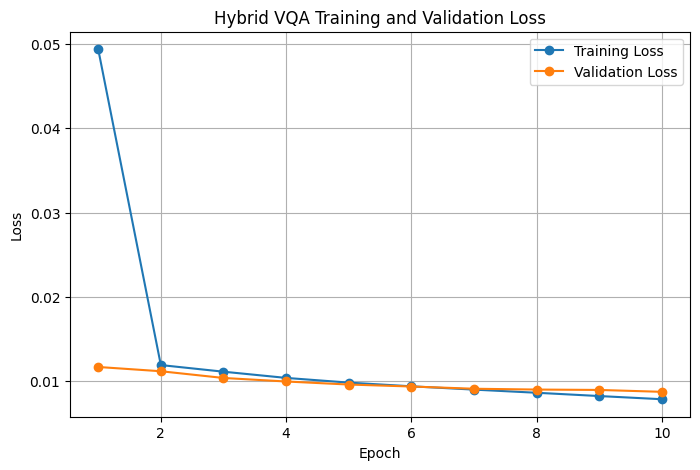

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(train_losses) + 1),
    train_losses,
    marker='o',
    label='Training Loss'
)

plt.plot(
    range(1, len(val_losses) + 1),
    val_losses,
    marker='o',
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Hybrid VQA Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.show()

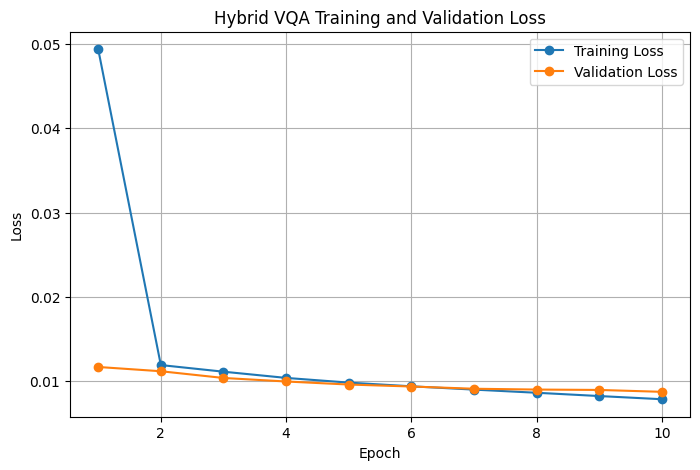

Loss graph saved successfully!
Saved to: /content/drive/MyDrive/VQA_Project/training_validation_loss.png


In [29]:
loss_plot_path = os.path.join(
    project_path,
    'training_validation_loss.png'
)

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(train_losses) + 1),
    train_losses,
    marker='o',
    label='Training Loss'
)

plt.plot(
    range(1, len(val_losses) + 1),
    val_losses,
    marker='o',
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Hybrid VQA Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.savefig(
    loss_plot_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Loss graph saved successfully!")
print("Saved to:", loss_plot_path)

In [30]:
model_path = os.path.join(
    project_path,
    'vqa_hybrid_model.pth'
)

torch.save(
    model.state_dict(),
    model_path
)

print("Hybrid VQA model saved successfully!")
print("Saved to:", model_path)

Hybrid VQA model saved successfully!
Saved to: /content/drive/MyDrive/VQA_Project/vqa_hybrid_model.pth


In [31]:
import torch

# Create a fresh model
evaluation_model = VQAHybridModel(
    image_dim=2048,
    text_dim=768,
    hidden_dim=512,
    num_answers=len(answer_space)
).to(device)

# Path of saved model
model_path = os.path.join(
    project_path,
    'vqa_hybrid_model.pth'
)

# Load trained weights
evaluation_model.load_state_dict(
    torch.load(
        model_path,
        map_location=device
    )
)

evaluation_model.eval()

print("Trained Hybrid VQA model loaded successfully!")

Trained Hybrid VQA model loaded successfully!


In [32]:
all_predictions = []
all_targets = []

evaluation_model.eval()

with torch.no_grad():

    for image_features, text_features, targets in eval_loader:

        image_features = image_features.to(device)
        text_features = text_features.to(device)

        outputs = evaluation_model(
            image_features,
            text_features
        )

        # Convert logits to probabilities
        probabilities = torch.sigmoid(outputs)

        # Convert probabilities to binary predictions
        predictions = (
            probabilities >= 0.5
        ).float()

        all_predictions.append(
            predictions.cpu()
        )

        all_targets.append(
            targets
        )

all_predictions = torch.cat(
    all_predictions,
    dim=0
)

all_targets = torch.cat(
    all_targets,
    dim=0
)

print("Prediction shape:", all_predictions.shape)
print("Target shape:", all_targets.shape)

Prediction shape: torch.Size([5673, 582])
Target shape: torch.Size([5673, 582])


In [33]:
from sklearn.metrics import f1_score, jaccard_score

# Convert tensors to NumPy
predictions_np = all_predictions.numpy()
targets_np = all_targets.numpy()

# Exact Match Accuracy
exact_match = (
    predictions_np == targets_np
).all(axis=1).mean()

# Micro F1
micro_f1 = f1_score(
    targets_np,
    predictions_np,
    average='micro',
    zero_division=0
)

# Jaccard score
jaccard = jaccard_score(
    targets_np,
    predictions_np,
    average='samples',
    zero_division=0
)

print("=" * 50)
print("HYBRID VQA EVALUATION RESULTS")
print("=" * 50)

print(f"Exact Match Accuracy : {exact_match * 100:.2f}%")
print(f"Micro F1 Score       : {micro_f1 * 100:.2f}%")
print(f"Jaccard Score        : {jaccard * 100:.2f}%")

print("=" * 50)

HYBRID VQA EVALUATION RESULTS
Exact Match Accuracy : 4.81%
Micro F1 Score       : 10.48%
Jaccard Score        : 5.46%


In [34]:
import pandas as pd

results = {
    "Metric": [
        "Exact Match Accuracy",
        "Micro F1 Score",
        "Jaccard Score"
    ],
    "Value": [
        exact_match * 100,
        micro_f1 * 100,
        jaccard * 100
    ]
}

results_df = pd.DataFrame(results)

results_path = os.path.join(
    project_path,
    'evaluation_results.csv'
)

results_df.to_csv(
    results_path,
    index=False
)

print("Evaluation results saved successfully!")
print("Saved to:", results_path)

print("\nFinal Results:")
print(results_df)

Evaluation results saved successfully!
Saved to: /content/drive/MyDrive/VQA_Project/evaluation_results.csv

Final Results:
                 Metric      Value
0  Exact Match Accuracy   4.812269
1        Micro F1 Score  10.477107
2         Jaccard Score   5.461249


In [35]:
id_to_answer = {
    idx: answer
    for idx, answer in enumerate(answer_space)
}

print("=" * 70)
print("SAMPLE VQA PREDICTIONS")
print("=" * 70)

num_samples = 10

for i in range(num_samples):

    # Get predicted probabilities
    image_features = eval_image_features[i].unsqueeze(0).to(device)
    text_features = eval_text_features[i].unsqueeze(0).to(device)

    with torch.no_grad():
        output = evaluation_model(
            image_features,
            text_features
        )

        probabilities = torch.sigmoid(output)[0]

    # Get top 5 predictions
    top_values, top_indices = torch.topk(
        probabilities,
        k=5
    )

    predicted_answers = [
        id_to_answer[idx.item()]
        for idx in top_indices
    ]

    question = eval_df.iloc[i]['question']
    actual_answer = eval_df.iloc[i]['answer']

    print(f"\nExample {i + 1}")
    print("-" * 70)
    print("Question:", question)
    print("Actual answer:", actual_answer)
    print("Top predictions:")

    for answer, probability in zip(
        predicted_answers,
        top_values
    ):
        print(
            f"  {answer} "
            f"({probability.item() * 100:.2f}%)"
        )

SAMPLE VQA PREDICTIONS

Example 1
----------------------------------------------------------------------
Question: what is on the left side of the white oven on the floor and on right side of the blue armchair
Actual answer: garbage_bin
Top predictions:
  bag (6.27%)
  microwave (5.57%)
  lamp (3.72%)
  hair_dryer (3.10%)
  television (3.08%)

Example 2
----------------------------------------------------------------------
Question: what is on the left side of the fire extinguisher and on the right side of the chair
Actual answer: table
Top predictions:
  bag (5.21%)
  garbage_bin (2.71%)
  lamp (2.59%)
  microwave (2.57%)
  television (2.48%)

Example 3
----------------------------------------------------------------------
Question: what is between the the two white and black garbage bins
Actual answer: chair
Top predictions:
  television (5.54%)
  door (5.16%)
  chair (5.10%)
  garbage_bin (3.77%)
  printer (2.24%)

Example 4
----------------------------------------------------------

In [36]:
import torch

top1_correct = 0
top3_correct = 0
top5_correct = 0
total = len(eval_df)

evaluation_model.eval()

with torch.no_grad():

    for image_features, text_features, targets in eval_loader:

        image_features = image_features.to(device)
        text_features = text_features.to(device)

        outputs = evaluation_model(
            image_features,
            text_features
        )

        probabilities = torch.sigmoid(outputs)

        # Top 5 predictions
        _, top5_indices = torch.topk(
            probabilities,
            k=5,
            dim=1
        )

        targets = targets.cpu()

        for i in range(len(targets)):

            true_indices = torch.where(
                targets[i] > 0
            )[0]

            predicted = top5_indices[i].cpu()

            # Top-1
            if predicted[0] in true_indices:
                top1_correct += 1

            # Top-3
            if any(
                p in true_indices
                for p in predicted[:3]
            ):
                top3_correct += 1

            # Top-5
            if any(
                p in true_indices
                for p in predicted[:5]
            ):
                top5_correct += 1


top1_accuracy = top1_correct / total
top3_accuracy = top3_correct / total
top5_accuracy = top5_correct / total

print("=" * 50)
print("TOP-K VQA RESULTS")
print("=" * 50)

print(f"Top-1 Accuracy: {top1_accuracy * 100:.2f}%")
print(f"Top-3 Accuracy: {top3_accuracy * 100:.2f}%")
print(f"Top-5 Accuracy: {top5_accuracy * 100:.2f}%")

print("=" * 50)

TOP-K VQA RESULTS
Top-1 Accuracy: 22.19%
Top-3 Accuracy: 42.39%
Top-5 Accuracy: 52.72%


In [37]:
import torch
import torch.nn as nn


class ImprovedVQAModel(nn.Module):

    def __init__(
        self,
        image_dim=2048,
        text_dim=768,
        hidden_dim=512,
        num_answers=582
    ):
        super().__init__()

        # Image feature projection
        self.image_projection = nn.Sequential(
            nn.Linear(image_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        # Question feature projection
        self.text_projection = nn.Sequential(
            nn.Linear(text_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        # Multimodal fusion
        self.fusion = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        # Answer classifier
        self.classifier = nn.Linear(
            hidden_dim,
            num_answers
        )

    def forward(self, image_features, text_features):

        # Project image features
        image_features = self.image_projection(
            image_features
        )

        # Project question features
        text_features = self.text_projection(
            text_features
        )

        # Combine image + question
        combined = torch.cat(
            [image_features, text_features],
            dim=1
        )

        # Multimodal fusion
        fused = self.fusion(combined)

        # Answer prediction
        output = self.classifier(fused)

        return output


improved_model = ImprovedVQAModel(
    image_dim=2048,
    text_dim=768,
    hidden_dim=512,
    num_answers=len(answer_space)
).to(device)

print("Improved Hybrid VQA model created!")
print("Answer classes:", len(answer_space))
print("Device:", device)

Improved Hybrid VQA model created!
Answer classes: 582
Device: cuda


In [38]:
criterion_improved = nn.BCEWithLogitsLoss()

optimizer_improved = torch.optim.AdamW(
    improved_model.parameters(),
    lr=0.0005,
    weight_decay=0.0001
)

print("Loss: BCEWithLogitsLoss")
print("Optimizer: AdamW")
print("Learning rate: 0.0005")

Loss: BCEWithLogitsLoss
Optimizer: AdamW
Learning rate: 0.0005


In [39]:
import time

num_epochs_improved = 10

improved_train_losses = []
improved_val_losses = []

print("Starting improved Hybrid VQA training...")
print("=" * 65)

for epoch in range(num_epochs_improved):

    # -------------------------
    # Training
    # -------------------------
    improved_model.train()

    running_train_loss = 0.0
    start_time = time.time()

    for image_features, text_features, targets in train_loader:

        image_features = image_features.to(device)
        text_features = text_features.to(device)
        targets = targets.to(device)

        optimizer_improved.zero_grad()

        outputs = improved_model(
            image_features,
            text_features
        )

        loss = criterion_improved(
            outputs,
            targets
        )

        loss.backward()

        optimizer_improved.step()

        running_train_loss += loss.item()

    train_loss = (
        running_train_loss /
        len(train_loader)
    )

    improved_train_losses.append(train_loss)

    # -------------------------
    # Validation
    # -------------------------
    improved_model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for image_features, text_features, targets in val_loader:

            image_features = image_features.to(device)
            text_features = text_features.to(device)
            targets = targets.to(device)

            outputs = improved_model(
                image_features,
                text_features
            )

            loss = criterion_improved(
                outputs,
                targets
            )

            running_val_loss += loss.item()

    val_loss = (
        running_val_loss /
        len(val_loader)
    )

    improved_val_losses.append(val_loss)

    elapsed = time.time() - start_time

    print(
        f"Epoch [{epoch + 1}/{num_epochs_improved}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Time: {elapsed:.1f}s"
    )

print("=" * 65)
print("Improved model training completed!")

Starting improved Hybrid VQA training...
Epoch [1/10] Train Loss: 0.0710 Val Loss: 0.0121 Time: 0.9s
Epoch [2/10] Train Loss: 0.0125 Val Loss: 0.0117 Time: 0.8s
Epoch [3/10] Train Loss: 0.0121 Val Loss: 0.0112 Time: 0.9s
Epoch [4/10] Train Loss: 0.0116 Val Loss: 0.0107 Time: 0.7s
Epoch [5/10] Train Loss: 0.0111 Val Loss: 0.0104 Time: 0.4s
Epoch [6/10] Train Loss: 0.0107 Val Loss: 0.0100 Time: 0.4s
Epoch [7/10] Train Loss: 0.0103 Val Loss: 0.0097 Time: 0.4s
Epoch [8/10] Train Loss: 0.0099 Val Loss: 0.0096 Time: 0.4s
Epoch [9/10] Train Loss: 0.0097 Val Loss: 0.0094 Time: 0.4s
Epoch [10/10] Train Loss: 0.0094 Val Loss: 0.0093 Time: 0.4s
Improved model training completed!


In [40]:
improved_model_path = os.path.join(
    project_path,
    'vqa_hybrid_model_v2.pth'
)

torch.save(
    improved_model.state_dict(),
    improved_model_path
)

print("Improved model saved successfully!")
print(improved_model_path)

Improved model saved successfully!
/content/drive/MyDrive/VQA_Project/vqa_hybrid_model_v2.pth


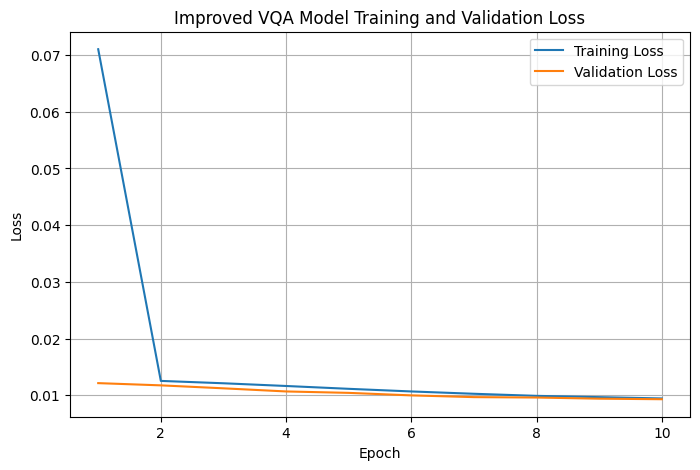

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, num_epochs_improved + 1),
    improved_train_losses,
    label='Training Loss'
)

plt.plot(
    range(1, num_epochs_improved + 1),
    improved_val_losses,
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Improved VQA Model Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.show()

In [42]:
improved_model.eval()

all_predictions = []
all_targets = []

with torch.no_grad():

    for image_features, text_features, targets in eval_loader:

        image_features = image_features.to(device)
        text_features = text_features.to(device)

        outputs = improved_model(
            image_features,
            text_features
        )

        probabilities = torch.sigmoid(outputs)

        all_predictions.append(
            probabilities.cpu()
        )

        all_targets.append(
            targets
        )

all_predictions = torch.cat(all_predictions)
all_targets = torch.cat(all_targets)

print("Predictions shape:", all_predictions.shape)
print("Targets shape:", all_targets.shape)

Predictions shape: torch.Size([5673, 582])
Targets shape: torch.Size([5673, 582])


In [43]:
def calculate_top_k_accuracy(
    predictions,
    targets,
    k
):
    top_k = torch.topk(
        predictions,
        k=k,
        dim=1
    ).indices

    correct = 0

    for i in range(len(targets)):

        true_answers = torch.where(
            targets[i] > 0
        )[0]

        predicted_answers = top_k[i]

        if any(
            answer.item() in true_answers.tolist()
            for answer in predicted_answers
        ):
            correct += 1

    return 100 * correct / len(targets)


v2_top1 = calculate_top_k_accuracy(
    all_predictions,
    all_targets,
    1
)

v2_top3 = calculate_top_k_accuracy(
    all_predictions,
    all_targets,
    3
)

v2_top5 = calculate_top_k_accuracy(
    all_predictions,
    all_targets,
    5
)

print(f"V2 Top-1 Accuracy: {v2_top1:.2f}%")
print(f"V2 Top-3 Accuracy: {v2_top3:.2f}%")
print(f"V2 Top-5 Accuracy: {v2_top5:.2f}%")

V2 Top-1 Accuracy: 18.88%
V2 Top-3 Accuracy: 35.45%
V2 Top-5 Accuracy: 47.70%


In [44]:
import torch
import torch.nn as nn
import torch.nn.functional as F


# Original V1 architecture
v3_model = VQAHybridModel(
    image_dim=2048,
    text_dim=768,
    hidden_dim=512,
    num_answers=len(answer_space)
).to(device)


# Soft-target cross-entropy loss
def soft_target_cross_entropy(logits, targets):

    # Convert multi-answer targets into probabilities
    target_probabilities = (
        targets /
        targets.sum(
            dim=1,
            keepdim=True
        ).clamp_min(1.0)
    )

    log_probabilities = F.log_softmax(
        logits,
        dim=1
    )

    loss = -(
        target_probabilities *
        log_probabilities
    ).sum(dim=1).mean()

    return loss


optimizer_v3 = torch.optim.AdamW(
    v3_model.parameters(),
    lr=0.0005,
    weight_decay=0.0001
)

print("V3 model created successfully!")
print("Loss: Soft-target Cross Entropy")
print("Optimizer: AdamW")
print("Learning rate: 0.0005")

V3 model created successfully!
Loss: Soft-target Cross Entropy
Optimizer: AdamW
Learning rate: 0.0005


In [45]:
num_epochs_v3 = 10

v3_train_losses = []
v3_val_losses = []

print("Starting V3 training...")
print("=" * 65)

for epoch in range(num_epochs_v3):

    # -------------------------
    # Training
    # -------------------------
    v3_model.train()

    running_train_loss = 0.0

    for image_features, text_features, targets in train_loader:

        image_features = image_features.to(device)
        text_features = text_features.to(device)
        targets = targets.to(device)

        optimizer_v3.zero_grad()

        outputs = v3_model(
            image_features,
            text_features
        )

        loss = soft_target_cross_entropy(
            outputs,
            targets
        )

        loss.backward()
        optimizer_v3.step()

        running_train_loss += loss.item()

    train_loss = (
        running_train_loss /
        len(train_loader)
    )

    v3_train_losses.append(train_loss)

    # -------------------------
    # Validation
    # -------------------------
    v3_model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for image_features, text_features, targets in val_loader:

            image_features = image_features.to(device)
            text_features = text_features.to(device)
            targets = targets.to(device)

            outputs = v3_model(
                image_features,
                text_features
            )

            loss = soft_target_cross_entropy(
                outputs,
                targets
            )

            running_val_loss += loss.item()

    val_loss = (
        running_val_loss /
        len(val_loader)
    )

    v3_val_losses.append(val_loss)

    print(
        f"Epoch [{epoch + 1}/{num_epochs_v3}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f}"
    )

print("=" * 65)
print("V3 training completed!")

Starting V3 training...
Epoch [1/10] Train Loss: 4.8793 Val Loss: 4.2169
Epoch [2/10] Train Loss: 3.9267 Val Loss: 3.8694
Epoch [3/10] Train Loss: 3.4323 Val Loss: 3.6805
Epoch [4/10] Train Loss: 3.0608 Val Loss: 3.5821
Epoch [5/10] Train Loss: 2.7272 Val Loss: 3.6045
Epoch [6/10] Train Loss: 2.4054 Val Loss: 3.5730
Epoch [7/10] Train Loss: 2.1257 Val Loss: 3.6539
Epoch [8/10] Train Loss: 1.8727 Val Loss: 3.7179
Epoch [9/10] Train Loss: 1.6488 Val Loss: 3.8918
Epoch [10/10] Train Loss: 1.4509 Val Loss: 4.0209
V3 training completed!


In [46]:
# Create a fresh V3 model

v3_model = VQAHybridModel(
    image_dim=2048,
    text_dim=768,
    hidden_dim=512,
    num_answers=len(answer_space)
).to(device)

optimizer_v3 = torch.optim.AdamW(
    v3_model.parameters(),
    lr=0.0005,
    weight_decay=0.0001
)

num_epochs_v3 = 10

best_val_loss = float('inf')
best_epoch = 0

v3_train_losses = []
v3_val_losses = []

best_model_path = os.path.join(
    project_path,
    'vqa_hybrid_model_v3_best.pth'
)

print("Training V3 with best-model checkpointing...")
print("=" * 65)

for epoch in range(num_epochs_v3):

    # -------------------------
    # Training
    # -------------------------
    v3_model.train()

    running_train_loss = 0.0

    for image_features, text_features, targets in train_loader:

        image_features = image_features.to(device)
        text_features = text_features.to(device)
        targets = targets.to(device)

        optimizer_v3.zero_grad()

        outputs = v3_model(
            image_features,
            text_features
        )

        loss = soft_target_cross_entropy(
            outputs,
            targets
        )

        loss.backward()
        optimizer_v3.step()

        running_train_loss += loss.item()

    train_loss = (
        running_train_loss /
        len(train_loader)
    )

    v3_train_losses.append(train_loss)

    # -------------------------
    # Validation
    # -------------------------
    v3_model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for image_features, text_features, targets in val_loader:

            image_features = image_features.to(device)
            text_features = text_features.to(device)
            targets = targets.to(device)

            outputs = v3_model(
                image_features,
                text_features
            )

            loss = soft_target_cross_entropy(
                outputs,
                targets
            )

            running_val_loss += loss.item()

    val_loss = (
        running_val_loss /
        len(val_loader)
    )

    v3_val_losses.append(val_loss)

    # -------------------------
    # Save best model
    # -------------------------
    if val_loss < best_val_loss:

        best_val_loss = val_loss
        best_epoch = epoch + 1

        torch.save(
            v3_model.state_dict(),
            best_model_path
        )

        saved_text = " <-- BEST MODEL SAVED"

    else:
        saved_text = ""

    print(
        f"Epoch [{epoch + 1}/{num_epochs_v3}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f}"
        f"{saved_text}"
    )

print("=" * 65)

print(
    f"Best epoch: {best_epoch}"
)

print(
    f"Best validation loss: {best_val_loss:.4f}"
)

print(
    "Best V3 model saved at:"
)

print(best_model_path)

Training V3 with best-model checkpointing...
Epoch [1/10] Train Loss: 4.8991 Val Loss: 4.2892 <-- BEST MODEL SAVED
Epoch [2/10] Train Loss: 3.9480 Val Loss: 3.8950 <-- BEST MODEL SAVED
Epoch [3/10] Train Loss: 3.4685 Val Loss: 3.6719 <-- BEST MODEL SAVED
Epoch [4/10] Train Loss: 3.0808 Val Loss: 3.6547 <-- BEST MODEL SAVED
Epoch [5/10] Train Loss: 2.7459 Val Loss: 3.5871 <-- BEST MODEL SAVED
Epoch [6/10] Train Loss: 2.4218 Val Loss: 3.5881
Epoch [7/10] Train Loss: 2.1362 Val Loss: 3.6304
Epoch [8/10] Train Loss: 1.8678 Val Loss: 3.7454
Epoch [9/10] Train Loss: 1.6431 Val Loss: 3.8799
Epoch [10/10] Train Loss: 1.4352 Val Loss: 4.0168
Best epoch: 5
Best validation loss: 3.5871
Best V3 model saved at:
/content/drive/MyDrive/VQA_Project/vqa_hybrid_model_v3_best.pth


In [47]:
import os
import shutil
import pandas as pd

# Original V1 model
v1_model_path = os.path.join(
    project_path,
    'vqa_hybrid_model.pth'
)

# Final model name
final_model_path = os.path.join(
    project_path,
    'final_vqa_model.pth'
)

# Copy V1 as the final model
shutil.copy2(
    v1_model_path,
    final_model_path
)

# Model comparison
results = pd.DataFrame({
    'Model': [
        'V1 - Original Hybrid',
        'V2 - Improved Fusion'
    ],
    'Top-1 Accuracy (%)': [
        22.19,
        18.88
    ],
    'Top-3 Accuracy (%)': [
        42.39,
        35.45
    ],
    'Top-5 Accuracy (%)': [
        52.72,
        47.70
    ]
})

results_path = os.path.join(
    project_path,
    'model_comparison.csv'
)

results.to_csv(
    results_path,
    index=False
)

print("=" * 60)
print("VQA PROJECT FINALIZED")
print("=" * 60)

print("\nFinal model:")
print(final_model_path)

print("\nComparison file:")
print(results_path)

print("\nFINAL MODEL: V1 - Original Hybrid Model")
print("Top-1 Accuracy: 22.19%")
print("Top-3 Accuracy: 42.39%")
print("Top-5 Accuracy: 52.72%")

print("\nAll important project files are stored in:")
print(project_path)

VQA PROJECT FINALIZED

Final model:
/content/drive/MyDrive/VQA_Project/final_vqa_model.pth

Comparison file:
/content/drive/MyDrive/VQA_Project/model_comparison.csv

FINAL MODEL: V1 - Original Hybrid Model
Top-1 Accuracy: 22.19%
Top-3 Accuracy: 42.39%
Top-5 Accuracy: 52.72%

All important project files are stored in:
/content/drive/MyDrive/VQA_Project


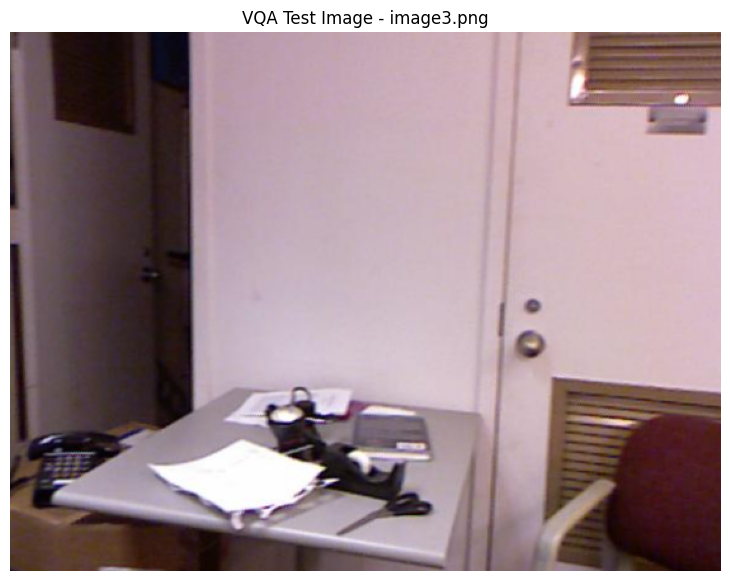

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
plt.imshow(image)
plt.axis("off")
plt.title("VQA Test Image - image3.png")
plt.show()

In [48]:
# ============================================================
# FINAL END-TO-END VQA TEST
# ============================================================

import os
import torch
import torch.nn as nn
from PIL import Image
from torchvision import models, transforms
from transformers import BertTokenizer, BertModel

# ------------------------------------------------------------
# 1. Paths
# ------------------------------------------------------------

project_path = "/content/drive/MyDrive/VQA_Project"

model_path = os.path.join(
    project_path,
    "vqa_hybrid_model.pth"
)

image_path = os.path.join(
    project_path,
    "DAQUAR",
    "images",
    "image3.png"
)

answer_space_path = os.path.join(
    project_path,
    "DAQUAR",
    "answer_space.txt"
)

# ------------------------------------------------------------
# 2. Device
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

# ------------------------------------------------------------
# 3. Load answer space
# ------------------------------------------------------------

with open(answer_space_path, "r") as f:
    answer_space = [
        line.strip()
        for line in f
        if line.strip()
    ]

print("Number of answers:", len(answer_space))

# ------------------------------------------------------------
# 4. Load ResNet50
# ------------------------------------------------------------

image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

resnet = models.resnet50(
    weights=models.ResNet50_Weights.DEFAULT
)

resnet = nn.Sequential(
    *list(resnet.children())[:-1]
)

resnet = resnet.to(device)
resnet.eval()

# ------------------------------------------------------------
# 5. Load BERT
# ------------------------------------------------------------

tokenizer = BertTokenizer.from_pretrained(
    "bert-base-uncased"
)

bert = BertModel.from_pretrained(
    "bert-base-uncased"
)

bert = bert.to(device)
bert.eval()

# ------------------------------------------------------------
# 6. Define original V1 model
# ------------------------------------------------------------

class VQAHybridModel(nn.Module):

    def __init__(
        self,
        image_dim=2048,
        text_dim=768,
        hidden_dim=512,
        num_answers=582
    ):
        super().__init__()

        self.image_projection = nn.Linear(
            image_dim,
            hidden_dim
        )

        self.text_projection = nn.Linear(
            text_dim,
            hidden_dim
        )

        self.attention = nn.Sequential(
            nn.Linear(
                hidden_dim * 2,
                hidden_dim
            ),
            nn.Tanh(),
            nn.Linear(
                hidden_dim,
                1
            )
        )

        self.fusion = nn.Sequential(
            nn.Linear(
                hidden_dim * 2,
                hidden_dim
            ),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        self.classifier = nn.Linear(
            hidden_dim,
            num_answers
        )

    def forward(
        self,
        image_features,
        text_features
    ):

        image_features = self.image_projection(
            image_features
        )

        text_features = self.text_projection(
            text_features
        )

        combined = torch.cat(
            [
                image_features,
                text_features
            ],
            dim=1
        )

        attention_weight = torch.sigmoid(
            self.attention(combined)
        )

        image_attended = (
            image_features *
            attention_weight
        )

        text_attended = (
            text_features *
            attention_weight
        )

        fused = torch.cat(
            [
                image_attended,
                text_attended
            ],
            dim=1
        )

        fused = self.fusion(fused)

        output = self.classifier(fused)

        return output


# ------------------------------------------------------------
# 7. Load trained V1 model
# ------------------------------------------------------------

vqa_model = VQAHybridModel(
    image_dim=2048,
    text_dim=768,
    hidden_dim=512,
    num_answers=len(answer_space)
).to(device)

vqa_model.load_state_dict(
    torch.load(
        model_path,
        map_location=device
    )
)

vqa_model.eval()

print("V1 model loaded successfully!")

# ------------------------------------------------------------
# 8. Load REAL image
# ------------------------------------------------------------

image = Image.open(
    image_path
).convert("RGB")

print("Image loaded:", image_path)
print("Image size:", image.size)

image_tensor = image_transform(
    image
).unsqueeze(0).to(device)

# ------------------------------------------------------------
# 9. Extract REAL image features
# ------------------------------------------------------------

with torch.no_grad():

    image_features = resnet(
        image_tensor
    )

    image_features = image_features.view(
        image_features.size(0),
        -1
    )

print(
    "Image feature shape:",
    image_features.shape
)

# ------------------------------------------------------------
# 10. Ask a REAL question
# ------------------------------------------------------------

question = (
    "what is on the right side of the black "
    "telephone and on the left side of the red chair"
)

# ------------------------------------------------------------
# 11. Extract BERT question features
# ------------------------------------------------------------

inputs = tokenizer(
    question,
    return_tensors="pt",
    padding=True,
    truncation=True,
    max_length=64
)

inputs = {
    key: value.to(device)
    for key, value in inputs.items()
}

with torch.no_grad():

    bert_output = bert(
        **inputs
    )

    text_features = (
        bert_output
        .last_hidden_state[:, 0, :]
    )

print(
    "Question feature shape:",
    text_features.shape
)

# ------------------------------------------------------------
# 12. Predict answer
# ------------------------------------------------------------

with torch.no_grad():

    outputs = vqa_model(
        image_features,
        text_features
    )

    probabilities = torch.sigmoid(
        outputs
    )

# ------------------------------------------------------------
# 13. Get Top 5 answers
# ------------------------------------------------------------

top_values, top_indices = torch.topk(
    probabilities,
    k=5,
    dim=1
)

print()
print("=" * 60)
print("FINAL VQA TEST")
print("=" * 60)

print()
print("Question:")
print(question)

print()
print("Top 5 predictions:")

for i in range(5):

    answer = answer_space[
        top_indices[0][i].item()
    ]

    confidence = (
        top_values[0][i].item() * 100
    )

    print(
        f"{i + 1}. {answer} "
        f"({confidence:.2f}%)"
    )

print()
print("Dataset expected answer: desk")
print("=" * 60)

Device: cuda
Number of answers: 582


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


V1 model loaded successfully!
Image loaded: /content/drive/MyDrive/VQA_Project/DAQUAR/images/image3.png
Image size: (560, 425)
Image feature shape: torch.Size([1, 2048])
Question feature shape: torch.Size([1, 768])

FINAL VQA TEST

Question:
what is on the right side of the black telephone and on the left side of the red chair

Top 5 predictions:
1. telephone (12.26%)
2. laptop (7.35%)
3. bag (6.08%)
4. papers (5.52%)
5. paper (5.16%)

Dataset expected answer: desk


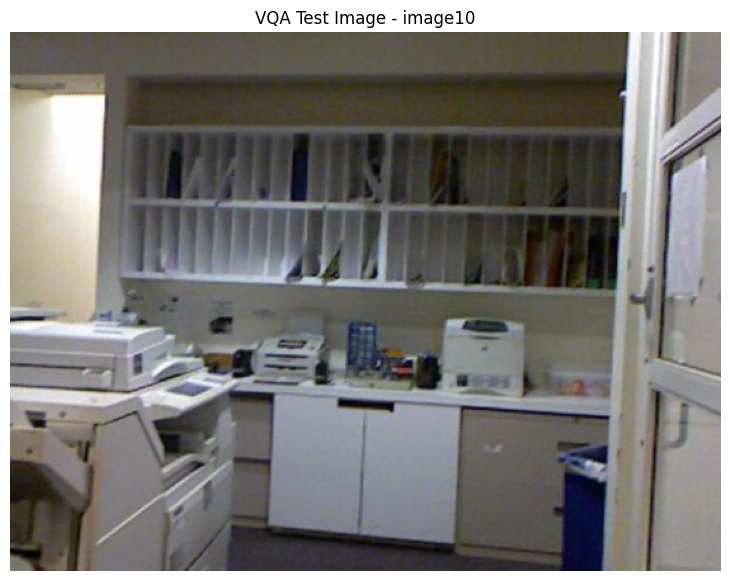

Image: image10
Path: /content/drive/MyDrive/VQA_Project/DAQUAR/images/image10.png


In [50]:
# Load and display another real DAQUAR image

import os
import matplotlib.pyplot as plt
from PIL import Image

image_id = "image10"

image_path = os.path.join(
    project_path,
    "DAQUAR",
    "images",
    image_id + ".png"
)

test_image = Image.open(image_path).convert("RGB")

plt.figure(figsize=(10, 7))
plt.imshow(test_image)
plt.axis("off")
plt.title(f"VQA Test Image - {image_id}")
plt.show()

print("Image:", image_id)
print("Path:", image_path)

In [51]:
# Show questions and answers for this image

image_questions = eval_df[
    eval_df["image_id"] == image_id
]

print(image_questions.to_string(index=False))

Empty DataFrame
Columns: [question, answer, image_id]
Index: []


In [52]:
# Pick an image that definitely exists in the evaluation dataset

test_row = eval_df.iloc[10]

image_id = test_row["image_id"]
question = test_row["question"]
actual_answer = test_row["answer"]

print("Image ID:", image_id)
print("Question:", question)
print("Expected answer:", actual_answer)

Image ID: image9
Question: what color is the red object in front of the wall on the left side of the desk
Expected answer: paper_tray


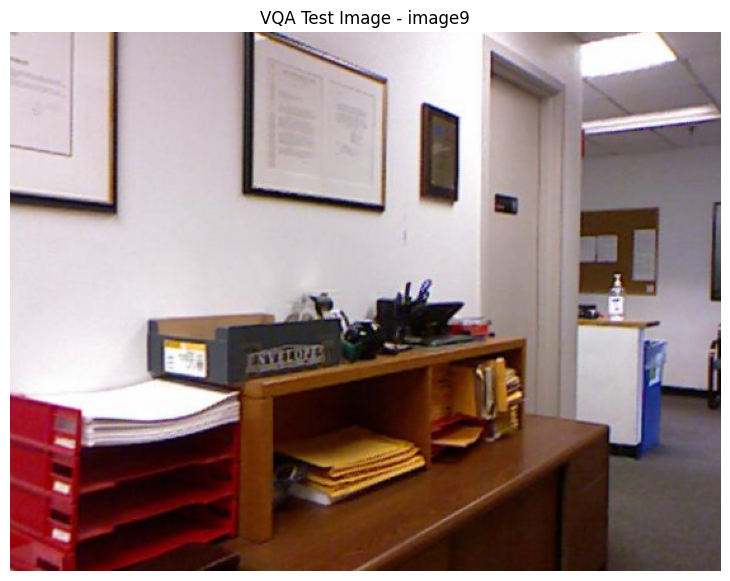

In [53]:
import os
import matplotlib.pyplot as plt
from PIL import Image

image_path = os.path.join(
    project_path,
    "DAQUAR",
    "images",
    image_id + ".png"
)

test_image = Image.open(
    image_path
).convert("RGB")

plt.figure(figsize=(10, 7))
plt.imshow(test_image)
plt.axis("off")
plt.title(f"VQA Test Image - {image_id}")
plt.show()

In [54]:
# Show questions and answers for this image

image_questions = eval_df[
    eval_df["image_id"] == image_id
]

print(image_questions.to_string(index=False))

                                                                           question                  answer image_id
     what color is the red object in front of the wall on the left side of the desk              paper_tray   image9
                                     what is above the desk in fornt of the scissor            hole_puncher   image9
                                    what is the largest blue object in this picture             garbage_bin   image9
                    what is on the wall on the left side of the door above the desk      framed_certificate   image9
                                               what is the object close to the wall      framed_certificate   image9
                                             what are stacked on the red paper rack                   paper   image9
                                  how many wall hanging frames are hung on the wall                       3   image9
                   what is kept on top of the storage table righ